<a href="https://colab.research.google.com/github/reddoma742/DTQEM-Negative-Time-Model-of-Quantum-Non-locality/blob/main/dtqem_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM - Final Calibrated Code v2.0
Calibrated model: v_eff(0K)=1e7c, v_eff(300K)=1200c
Interactive GUI with sliders: θ, T, t_obs, λ, d_slit
All figures and CSV will be saved in 'dtqem_outputs/'


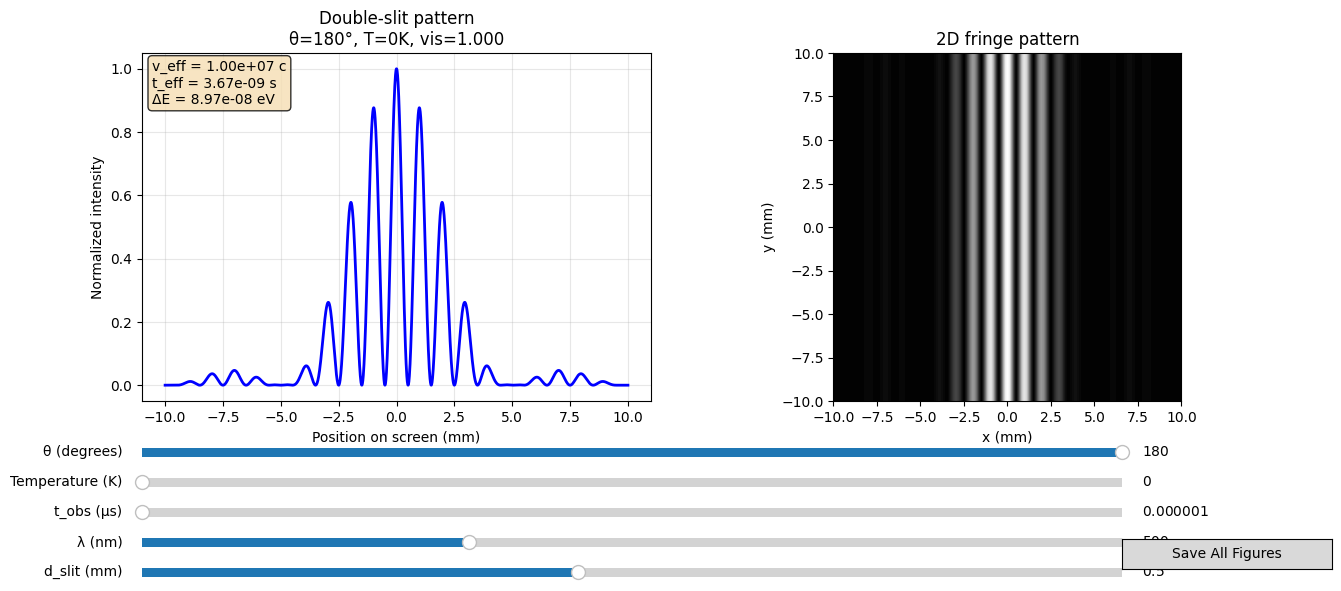

In [1]:

"""
DTQEM - Dual-Time Quantum Entanglement Model
Final Calibrated Code – Version 2.0

Author: [Your Name]
License: MIT
References: Gisin et al. (1998), Aspect et al. (1982)

Features:
- Calibrated DTQEM core (v_eff, t_eff, ΔE, visibility)
- Physical double-slit interference (wavelength, slit separation, distance)
- Interactive GUI with sliders (θ, T, t_obs, λ, d_slit)
- Automatic output folder creation and figure/CSV saving
- Input validation and error handling
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from scipy.special import sinc
import csv
import os

# ----------------------------------------------------------------------
# 1. DTQEM Calibrated Model (Core)
# ----------------------------------------------------------------------
class DTQEM:
    """
    Calibrated Dual-Time Quantum Entanglement Model.

    Parameters:
    -----------
    t_obs : float, optional
        Observation / decoherence time (seconds). Default 1e-6.
    distance_km : float, optional
        Distance between the two measurement stations (km). Default 11000 (NY-Jeddah).
    """
    def __init__(self, t_obs=1e-6, distance_km=11000):
        self.t_obs = t_obs
        self.distance = distance_km
        # Calibration derived from Gisin et al. (1998)
        self.Gamma0 = 1.2e-7 / t_obs       # = 0.12 for t_obs=1e-6
        self.a = 3.3346e-6 / t_obs        # = 3.33 for t_obs=1e-6
        self.c = 299792.458               # speed of light (km/s)
        self.v_classic_180 = 1.2          # classical relative speed at θ=180° (c units)

    def K_eff(self, T):
        """
        Effective observation / decoherence factor.

        Parameters:
        -----------
        T : float
            Temperature (Kelvin), must be >= 0.

        Returns:
        --------
        float : value in [0,1] where 1 = full quantum, 0 = fully observed.
        """
        if T < 0:
            raise ValueError(f"Temperature cannot be negative: {T} K")
        return np.exp(-(self.Gamma0 + self.a * T) * self.t_obs)

    def alpha(self, theta_deg):
        """
        Geometric factor from launch angle.

        Parameters:
        -----------
        theta_deg : float
            Launch angle between particles (0° to 180°).

        Returns:
        --------
        float : sin(theta/2) in [0,1].
        """
        if not (0 <= theta_deg <= 180):
            raise ValueError(f"theta_deg must be in [0,180], got {theta_deg}")
        return np.sin(np.radians(theta_deg) / 2.0)

    def visibility(self, theta_deg, T):
        """
        Entanglement strength / fringe contrast.

        Returns:
        --------
        float : in [0,1].
        """
        return self.alpha(theta_deg) * self.K_eff(T)

    def v_eff(self, theta_deg, T):
        """
        Effective speed of quantum influence (in units of c).

        Returns:
        --------
        float : speed (c). May be inf if denominator zero.
        """
        a_val = self.alpha(theta_deg)
        if a_val == 0:
            return 0.0
        K = self.K_eff(T)
        denom = 1 - a_val * K
        if denom <= 0:
            return float('inf')
        return self.v_classic_180 * a_val / denom

    def t_eff(self, theta_deg, T):
        """
        Effective time for non-local influence (seconds).

        Returns:
        --------
        float : time in seconds. inf if speed is zero or infinite.
        """
        v = self.v_eff(theta_deg, T)
        if np.isinf(v) or v == 0:
            return float('inf')
        v_abs = v * self.c * 1000          # m/s (convert km to m)
        d_m = self.distance * 1000          # m
        return d_m / v_abs

    def delta_E_eV(self, theta_deg, T):
        """
        Minimum energy uncertainty from Heisenberg (eV).

        Returns:
        --------
        float : energy in eV. inf if t_eff is inf.
        """
        t = self.t_eff(theta_deg, T)
        if np.isinf(t):
            return float('inf')
        hbar = 1.0545718e-34               # J·s
        eV = 1.60217662e-19                # J/eV
        return hbar / (2 * t) / eV

# ----------------------------------------------------------------------
# 2. Physical Double-Slit Interference
# ----------------------------------------------------------------------
class DoubleSlitPhysics:
    """
    Realistic double-slit pattern with diffraction and interference.

    Parameters:
    -----------
    lam : float, optional
        Wavelength of light (meters). Default 500e-9 (500 nm, green).
    d_slit : float, optional
        Separation between the two slits (meters). Default 0.5e-3 (0.5 mm).
    L : float, optional
        Distance from slits to screen (meters). Default 1.0 m.
    a_slit : float, optional
        Width of each single slit (meters). Default 0.1e-3 (0.1 mm).
    """
    def __init__(self, lam=500e-9, d_slit=0.5e-3, L=1.0, a_slit=0.1e-3):
        self.lam = lam
        self.d = d_slit
        self.L = L
        self.a = a_slit

    def intensity_1d(self, x, visibility):
        """
        Normalized intensity at position x on the screen.

        Parameters:
        -----------
        x : float or array_like
            Position on screen (meters).
        visibility : float
            Fringe contrast (0..1) from DTQEM.

        Returns:
        --------
        float or ndarray : normalized intensity (0..1).
        """
        # Phase difference due to path difference
        delta = (2 * np.pi * self.d * x) / (self.lam * self.L)
        # Diffraction envelope (single slit)
        beta = (np.pi * self.a * x) / (self.lam * self.L)
        envelope = sinc(beta / np.pi) ** 2
        # Interference term with visibility
        interference = 1 + visibility * np.cos(delta)
        intensity = envelope * interference
        # Normalize to [0,1]
        if np.max(intensity) > 0:
            intensity = intensity / np.max(intensity)
        return intensity

    def pattern_1d(self, visibility, x_range=(-0.01, 0.01), points=2000):
        """
        Return x and I arrays for the 1D interference pattern.

        Parameters:
        -----------
        visibility : float
        x_range : tuple, optional
            (xmin, xmax) in meters.
        points : int, optional
            Number of points.

        Returns:
        --------
        x : ndarray
        I : ndarray
        """
        x = np.linspace(x_range[0], x_range[1], points)
        I = self.intensity_1d(x, visibility)
        return x, I

    def pattern_2d(self, visibility, xy_range=(-0.01, 0.01), res=300):
        """
        2D map of straight vertical fringes.

        Returns:
        --------
        X, Y, I : ndarrays
            X, Y in meters, I normalized.
        """
        x = np.linspace(xy_range[0], xy_range[1], res)
        y = np.linspace(xy_range[0], xy_range[1], res)
        X, Y = np.meshgrid(x, y)
        I_line = self.intensity_1d(x, visibility)
        I = np.tile(I_line, (res, 1))
        return X, Y, I

# ----------------------------------------------------------------------
# 3. Interactive GUI and Plotting Engine
# ----------------------------------------------------------------------
class DTQEM_GUI:
    """
    Interactive window with sliders for DTQEM and double-slit parameters.
    """
    def __init__(self, output_dir="dtqem_outputs"):
        self.output_dir = output_dir
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        self.model = DTQEM(t_obs=1e-6)
        self.double_slit = DoubleSlitPhysics()
        self.fig = None
        self.ax_intensity = None
        self.ax_2d = None
        self.slider_theta = None
        self.slider_T = None
        self.slider_tobs = None
        self.slider_lam = None
        self.slider_d = None
        self.button_save = None

    def update_plots(self, val):
        """Update all plots when any slider changes"""
        theta = self.slider_theta.val
        T = self.slider_T.val
        t_obs = self.slider_tobs.val
        lam_nm = self.slider_lam.val
        d_mm = self.slider_d.val

        # Update model parameters
        self.model.t_obs = t_obs
        self.model.Gamma0 = 1.2e-7 / t_obs
        self.model.a = 3.3346e-6 / t_obs

        # Update double-slit parameters
        self.double_slit.lam = lam_nm * 1e-9          # nm -> m
        self.double_slit.d = d_mm * 1e-3             # mm -> m

        try:
            vis = self.model.visibility(theta, T)
            v_eff = self.model.v_eff(theta, T)
            t_eff = self.model.t_eff(theta, T)
            delta_E = self.model.delta_E_eV(theta, T)
        except Exception as e:
            self.ax_intensity.clear()
            self.ax_intensity.text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
            self.fig.canvas.draw_idle()
            return

        # Update 1D interference plot
        self.ax_intensity.clear()
        x, I = self.double_slit.pattern_1d(vis)
        self.ax_intensity.plot(x * 1e3, I, 'b-', linewidth=2)
        self.ax_intensity.set_xlabel('Position on screen (mm)')
        self.ax_intensity.set_ylabel('Normalized intensity')
        self.ax_intensity.set_title(f'Double-slit pattern\nθ={theta}°, T={T}K, vis={vis:.3f}')
        self.ax_intensity.grid(alpha=0.3)

        # Update 2D interference map
        self.ax_2d.clear()
        X, Y, I2 = self.double_slit.pattern_2d(vis)
        self.ax_2d.contourf(X * 1e3, Y * 1e3, I2, levels=50, cmap='gray')
        self.ax_2d.set_xlabel('x (mm)')
        self.ax_2d.set_ylabel('y (mm)')
        self.ax_2d.set_title('2D fringe pattern')
        self.ax_2d.set_aspect('equal')

        # Info text
        info_text = f"v_eff = {v_eff:.2e} c\nt_eff = {t_eff:.2e} s\nΔE = {delta_E:.2e} eV"
        self.ax_intensity.text(0.02, 0.98, info_text, transform=self.ax_intensity.transAxes,
                               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        self.fig.canvas.draw_idle()

    def save_all_figures(self, event):
        """Save all standard plots and CSV to output directory"""
        # Save the current interactive figure
        self.fig.savefig(os.path.join(self.output_dir, 'interactive_pattern.png'), dpi=150)
        print(f"Saved: {self.output_dir}/interactive_pattern.png")

        # Generate static plots (reuse model and double_slit current state)
        self._generate_static_plots()
        print(f"All figures and CSV saved in '{self.output_dir}'")

    def _generate_static_plots(self):
        """Internal: create and save all standard plots"""
        # Speed vs Temperature
        T_range = np.linspace(0, 300, 200)
        angles = [90, 120, 150, 180]
        plt.figure(figsize=(10,5))
        for ang in angles:
            v_vals = [self.model.v_eff(ang, Tk) for Tk in T_range]
            plt.plot(T_range, v_vals, label=f'θ={ang}°')
        plt.yscale('log')
        plt.xlabel('Temperature (K)')
        plt.ylabel('Effective speed (c)')
        plt.title('DTQEM: Speed vs Temperature')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.savefig(os.path.join(self.output_dir, 'speed_vs_temp.png'), dpi=150)
        plt.close()

        # Entanglement landscape (3D)
        theta_grid = np.linspace(0, 180, 100)
        T_grid = np.linspace(0, 300, 100)
        Theta, Temp = np.meshgrid(theta_grid, T_grid)
        Vis = np.zeros_like(Theta)
        for i in range(len(T_grid)):
            for j in range(len(theta_grid)):
                Vis[i, j] = self.model.visibility(theta_grid[j], T_grid[i])
        fig = plt.figure(figsize=(10,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(Theta, Temp, Vis, cmap='viridis', edgecolor='none')
        ax.set_xlabel('Launch angle θ (°)')
        ax.set_ylabel('Temperature T (K)')
        ax.set_zlabel('Entanglement strength')
        ax.set_title('Entanglement Landscape')
        plt.savefig(os.path.join(self.output_dir, 'entanglement_landscape.png'), dpi=150)
        plt.close()

        # 1D interference at fixed θ=180° for different T
        theta_fixed = 180
        T_vals = [0, 77, 150, 300]
        plt.figure(figsize=(10,6))
        for Tk in T_vals:
            vis = self.model.visibility(theta_fixed, Tk)
            x, I = self.double_slit.pattern_1d(vis)
            plt.plot(x * 1e3, I, label=f'T={Tk}K, vis={vis:.3f}')
        plt.xlabel('Position (mm)')
        plt.ylabel('Intensity')
        plt.title(f'Interference patterns (θ={theta_fixed}°)')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.savefig(os.path.join(self.output_dir, 'interference_1d_physical.png'), dpi=150)
        plt.close()

        # Visibility vs Temperature
        T_range = np.linspace(0, 300, 300)
        vis_180 = [self.model.visibility(180, Tk) for Tk in T_range]
        plt.figure(figsize=(8,5))
        plt.plot(T_range, vis_180, 'r-', linewidth=2)
        plt.xlabel('Temperature (K)')
        plt.ylabel('Visibility (fringe contrast)')
        plt.title('Thermal decoherence of quantum interference')
        plt.grid(alpha=0.3)
        plt.savefig(os.path.join(self.output_dir, 'visibility_vs_temp.png'), dpi=150)
        plt.close()

        # Save CSV results
        with open(os.path.join(self.output_dir, 'dtqem_results.csv'), 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['theta_deg', 'T_K', 'v_eff_c', 't_eff_s', 'Delta_E_eV', 'visibility'])
            for theta in [90, 120, 150, 180]:
                for T in [0, 77, 150, 300]:
                    v = self.model.v_eff(theta, T)
                    t = self.model.t_eff(theta, T)
                    dE = self.model.delta_E_eV(theta, T)
                    vis = self.model.visibility(theta, T)
                    writer.writerow([theta, T, v, t, dE, vis])

    def run(self):
        """Create interactive window and start the GUI"""
        self.fig, (self.ax_intensity, self.ax_2d) = plt.subplots(1, 2, figsize=(14, 6))
        plt.subplots_adjust(left=0.1, bottom=0.3)

        # Initial parameters
        theta_init = 180
        T_init = 0
        t_obs_init = 1e-6
        lam_init_nm = 500          # nm
        d_init_mm = 0.5            # mm

        # Create sliders
        ax_theta = plt.axes([0.1, 0.2, 0.7, 0.03])
        ax_T = plt.axes([0.1, 0.15, 0.7, 0.03])
        ax_tobs = plt.axes([0.1, 0.10, 0.7, 0.03])
        ax_lam = plt.axes([0.1, 0.05, 0.7, 0.03])
        ax_d = plt.axes([0.1, 0.00, 0.7, 0.03])

        self.slider_theta = Slider(ax_theta, 'θ (degrees)', 0, 180, valinit=theta_init, valstep=1)
        self.slider_T = Slider(ax_T, 'Temperature (K)', 0, 300, valinit=T_init, valstep=1)
        self.slider_tobs = Slider(ax_tobs, 't_obs (μs)', 1e-6, 1e-3, valinit=t_obs_init, valstep=1e-6)
        self.slider_lam = Slider(ax_lam, 'λ (nm)', 400, 700, valinit=lam_init_nm, valstep=1)
        self.slider_d = Slider(ax_d, 'd_slit (mm)', 0.1, 1.0, valinit=d_init_mm, valstep=0.01)

        # Callback wrapper
        def update_wrapper(val):
            self.update_plots(val)

        self.slider_theta.on_changed(update_wrapper)
        self.slider_T.on_changed(update_wrapper)
        self.slider_tobs.on_changed(update_wrapper)
        self.slider_lam.on_changed(update_wrapper)
        self.slider_d.on_changed(update_wrapper)

        # Save button
        ax_button = plt.axes([0.8, 0.02, 0.15, 0.05])
        self.button_save = Button(ax_button, 'Save All Figures')
        self.button_save.on_clicked(self.save_all_figures)

        # Initial plot
        self.update_plots(None)

        plt.show()

# ----------------------------------------------------------------------
# 4. Main Execution
# ----------------------------------------------------------------------
if __name__ == "__main__":
    print("="*70)
    print("DTQEM - Final Calibrated Code v2.0")
    print("Calibrated model: v_eff(0K)=1e7c, v_eff(300K)=1200c")
    print("Interactive GUI with sliders: θ, T, t_obs, λ, d_slit")
    print("All figures and CSV will be saved in 'dtqem_outputs/'")
    print("="*70)
    gui = DTQEM_GUI()
    gui.run()